<a href="https://colab.research.google.com/github/dagovenera/Caribbean-Brain-Coral-Classifier/blob/main/Caribbean_Brain_Coral_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Perform data augmentation: making slight modificacions to the originally uploaded coral images
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

datagen = ImageDataGenerator(
    rescale = 1/255,
    rotation_range = 45,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    shear_range = 0,
    zoom_range = [0.7, 1.3],
    validation_split = 0.2,
    horizontal_flip = True,
    vertical_flip = True,
)

In [2]:
#create training dataset
dataset_path = '/content/drive/MyDrive/Dataset'

datagen_train = datagen.flow_from_directory(dataset_path,
                                            target_size=(224,224),
                                            batch_size=10,
                                            shuffle = True,
                                            subset='training',
                                            class_mode='categorical',
)

Found 283 images belonging to 6 classes.


In [3]:
print('Class Indices:', datagen_train.class_indices)

Class Indices: {'Cnatans': 0, 'Dclivosa': 1, 'Dlabyrinthiformis': 2, 'Dstrigosa': 3, 'Maerolata': 4, 'Mmeandrites': 5}


In [4]:
#create validation/testing dataset
datagen_validation = datagen.flow_from_directory(dataset_path,
                                                 target_size=(224,224),
                                                 batch_size=10,
                                                 shuffle = True,
                                                 subset='validation',
)

Found 68 images belonging to 6 classes.


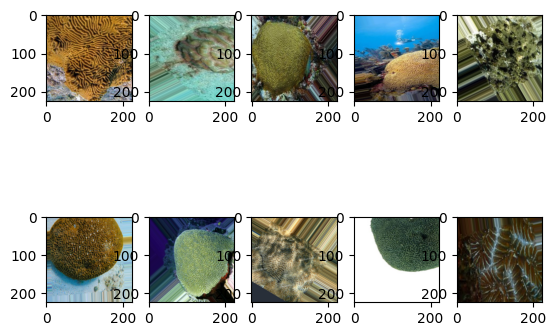

In [5]:
#visually check the first batch of generated images in the training dataset
import matplotlib.pyplot as plt

for imagenes, etiquetas in datagen_train:
  for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(imagenes[i])
  plt.show()
  break

In [6]:
#Checking that the number of batches is correct
len(datagen_train)

29

In [7]:
#Checking the first training batch
datagen_train[0]

(array([[[[0.5636248 , 0.37549895, 0.11001619],
          [0.65321547, 0.43943512, 0.1371452 ],
          [0.62721926, 0.4139014 , 0.1167546 ],
          ...,
          [0.55887604, 0.3841836 , 0.12162647],
          [0.60415214, 0.4423506 , 0.17512041],
          [0.54180324, 0.38875288, 0.1325166 ]],
 
         [[0.52023005, 0.3450053 , 0.09301013],
          [0.6502834 , 0.43708944, 0.13831805],
          [0.64481175, 0.430321  , 0.12496442],
          ...,
          [0.60030365, 0.42490044, 0.1524292 ],
          [0.5790486 , 0.41130856, 0.15591507],
          [0.47108182, 0.31049362, 0.08309162]],
 
         [[0.47683528, 0.3145117 , 0.07600407],
          [0.64735126, 0.4347438 , 0.13949087],
          [0.66240424, 0.44674066, 0.13317424],
          ...,
          [0.63011336, 0.45258337, 0.19823307],
          [0.553554  , 0.37485176, 0.14921562],
          [0.43366718, 0.25500247, 0.06469803]],
 
         ...,
 
         [[0.54964954, 0.5418064 , 0.5141386 ],
          [0.40794

### Transfer Learning with a Pre-trained Model

Use pre-trained VGG16 model as a feature extractor: load VGG16 model without its top classification layer, add new classification layers, and then train only these new layers.

In [8]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten

# Load VGG16 model with pre-trained ImageNet weights, excluding the top (classification) layer
conv_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze convolutional base to prevent its weights from being updated during training
conv_base.trainable = False

# Create a new model on top of the convolutional base
model_tl = tf.keras.Sequential([
    conv_base,
    Flatten(),
    Dense(256, activation='relu'),
    Dense(6, activation='softmax') # Output layer for 6 classes
])

model_tl.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,139,014 (80.64 MB)

 Trainable params: 6,424,326 (24.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Compile and train model. Good performance is expected because the convolutional base already has a strong understanding of image features.

In [9]:
model_tl.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

# for transfer learning use fewer epochs than you would use when building the full architecture from scratch
EPOCAS_TL = 30
training_tl = model_tl.fit(
    datagen_train,
    epochs=EPOCAS_TL,
    steps_per_epoch=len(datagen_train),
    validation_data=datagen_validation
)

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 305s 10s/step - accuracy: 0.2403 - loss: 3.1579 - val_accuracy: 0.3235 - val_loss: 1.6233
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 311ms/step - accuracy: 0.4558 - loss: 1.5572 - val_accuracy: 0.3824 - val_loss: 1.7514
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 268ms/step - accuracy: 0.6042 - loss: 1.1504 - val_accuracy: 0.4118 - val_loss: 1.4126
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 319ms/step - accuracy: 0.6396 - loss: 0.9897 - val_accuracy: 0.4853 - val_loss: 1.2949
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 287ms/step - accuracy: 0.6325 - loss: 0.9259 - val_accuracy: 0.3971 - val_loss: 1.5974
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 290ms/step - accuracy: 0.6608 - loss: 0.8601 - val_accuracy: 0.4412 - val_loss: 1.7453
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 322ms/step - accuracy: 0.6572 - loss: 0.8873 - val_accuracy: 0.4412 - val_loss: 1.6036
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 255ms/step - accuracy: 0.7527 - loss: 0.6612 - val_accuracy: 0.

### Fine-tuning the Model

Unfreeze last convolutional block of the conv_base (VGG16) and train entire model with a very small learning rate. This allows pre-trained layers to adapt more specifically to this coral dataset while still benefiting from general features learned from ImageNet. A lower learning rate will be used to avoid drastically changing the conv_base weights.

In [10]:
# Unfreeze the conv_base
conv_base.trainable = True

# Check how many layers are in the base model
print(f"Number of layers in conv_base: {len(conv_base.layers)}")

# Freeze all layers except for the last block
# VGG16 has 19 layers, then last conv block starts around layer 15 or 16
for layer in conv_base.layers[:-4]: # Unfreeze the last 4 layers
    layer.trainable = False

# Verify that the layers are correctly frozen/unfrozen
for layer in conv_base.layers:
    print(f"{layer.name}: {layer.trainable}")

Number of layers in conv_base: 19
input_layer: False
block1_conv1: False
block1_conv2: False
block1_pool: False
block2_conv1: False
block2_conv2: False
block2_pool: False
block3_conv1: False
block3_conv2: False
block3_conv3: False
block3_pool: False
block4_conv1: False
block4_conv2: False
block4_conv3: False
block4_pool: False
block5_conv1: True
block5_conv2: True
block5_conv3: True
block5_pool: True


With top convolutional layers unfrozen, recompile model with a very low learning rate.

In [11]:
from tensorflow.keras.optimizers import Adam

model_tl.compile(optimizer=Adam(learning_rate=1e-5), # Use very small learning rate for fine-tuning
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

EPOCAS_FINE_TUNE = 10 # Train for a few more epochs with fine-tuning
training_fine_tune = model_tl.fit(
    datagen_train,
    epochs=EPOCAS_FINE_TUNE,
    steps_per_epoch=len(datagen_train),
    validation_data=datagen_validation
)

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 445ms/step - accuracy: 0.8905 - loss: 0.2962 - val_accuracy: 0.6176 - val_loss: 1.2404
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 14s 313ms/step - accuracy: 0.9011 - loss: 0.2905 - val_accuracy: 0.5000 - val_loss: 1.7251
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 268ms/step - accuracy: 0.8551 - loss: 0.4186 - val_accuracy: 0.6029 - val_loss: 1.4007
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 299ms/step - accuracy: 0.8905 - loss: 0.2904 - val_accuracy: 0.5588 - val_loss: 1.4703
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 299ms/step - accuracy: 0.9117 - loss: 0.2444 - val_accuracy: 0.6618 - val_loss: 1.1038
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 264ms/step - accuracy: 0.9117 - loss: 0.2667 - val_accuracy: 0.5588 - val_loss: 1.3029
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 323ms/step - accuracy: 0.9187 - loss: 0.2638 - val_accuracy: 0.6029 - val_loss: 1.2454
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 280ms/step - accuracy: 0.9187 - loss: 0.2063 - val_accuracy: 

### Learning Rate Scheduling with ReduceLROnPlateau

Use ReduceLROnPlateau callback which monitors a quantity (e.g., validation loss) and if no improvement is seen for a "patience" number of epochs, learning rate is reduced by a factor.

In [12]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Define ReduceLROnPlateau callback
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',  # Monitor validation loss
    factor=0.5,          # Reduce learning rate by a factor of 0.5
    patience=3,          # Number of epochs with no improvement after which learning rate will be reduced
    min_lr=1e-7,         # Lower bound on the learning rate
    verbose=1
)

# Recompile model with slightly higher initial learning rate
model_tl.compile(
    optimizer=Adam(learning_rate=1e-4), # Start with 1e-4
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

EPOCAS_LRS = 15 # Train for a few more epochs with learning rate scheduling
print('Starting training with Learning Rate Scheduling...')
training_lrs = model_tl.fit(
    datagen_train,
    epochs=EPOCAS_LRS,
    steps_per_epoch=len(datagen_train),
    validation_data=datagen_validation,
    callbacks=[reduce_lr] # Add learning rate callback
)

Starting training with Learning Rate Scheduling...
Epoch 1/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 426ms/step - accuracy: 0.7350 - loss: 0.9429 - val_accuracy: 0.5735 - val_loss: 1.2539 - learning_rate: 1.0000e-04
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 268ms/step - accuracy: 0.8198 - loss: 0.5383 - val_accuracy: 0.5294 - val_loss: 1.2547 - learning_rate: 1.0000e-04
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 316ms/step - accuracy: 0.8269 - loss: 0.4827 - val_accuracy: 0.5882 - val_loss: 1.5356 - learning_rate: 1.0000e-04
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.8391 - loss: 0.4883
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 300ms/step - accuracy: 0.8127 - loss: 0.5193 - val_accuracy: 0.5294 - val_loss: 1.2545 - learning_rate: 1.0000e-04
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 280ms/step - accuracy: 0.8834 - loss: 0.2903 - val_accuracy: 0.6471 - val_loss: 1.0343 - learning_rate: 5.0000e-05
Epoch 6/15
29/29 

### Plot Training & Validation Curves

Visualize accuracy and loss for training and validation during all the training phases (transfer learning, fine-tuning, and learning rate scheduling) to observe the impact of each optimization step.

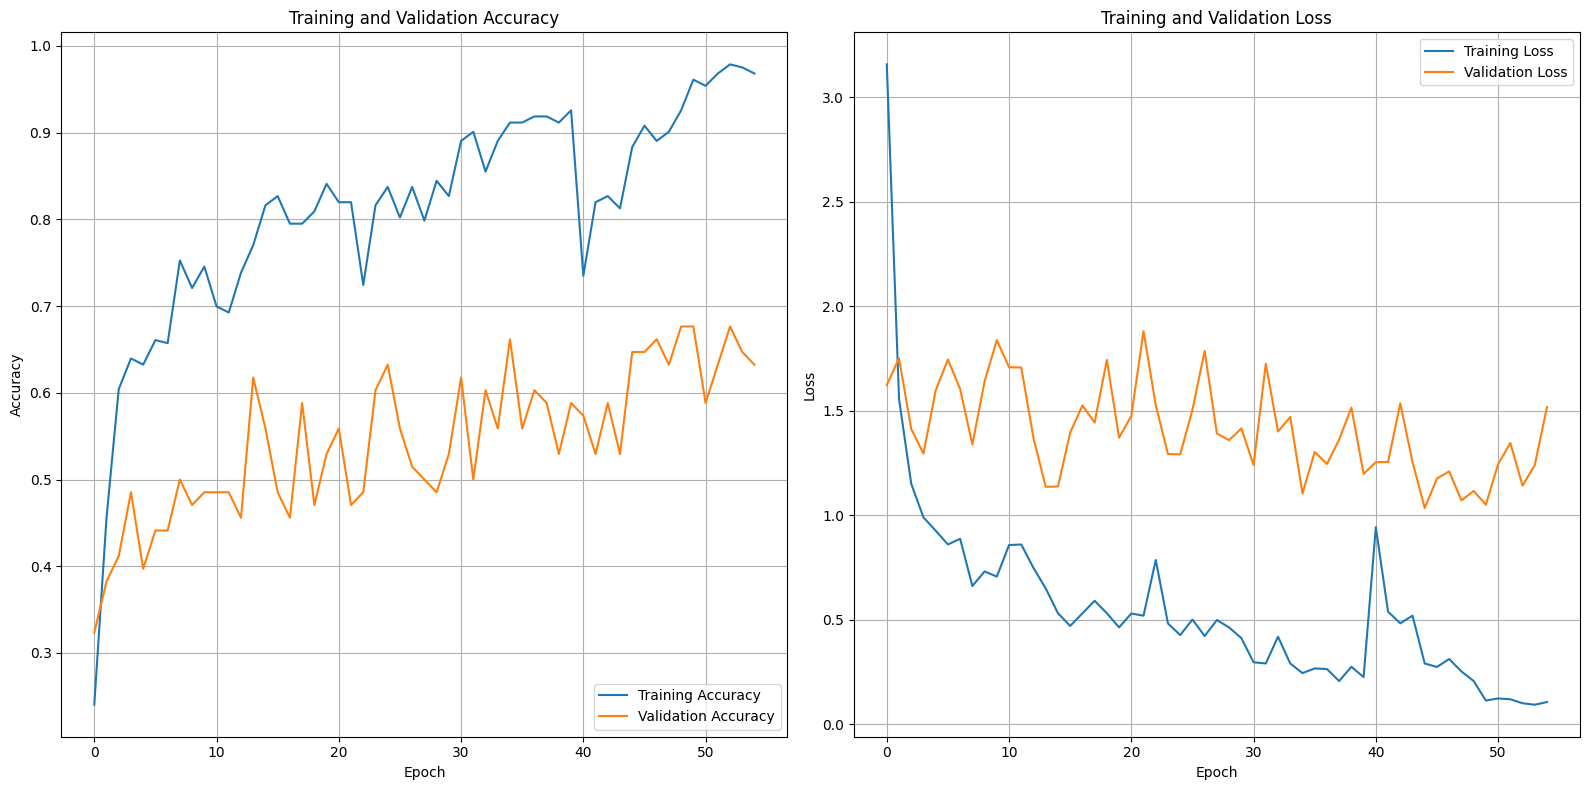

In [13]:
import matplotlib.pyplot as plt

# Combine histories for plotting
acc = training_tl.history['accuracy'] + training_fine_tune.history['accuracy'] + training_lrs.history['accuracy']
val_acc = training_tl.history['val_accuracy'] + training_fine_tune.history['val_accuracy'] + training_lrs.history['val_accuracy']

loss = training_tl.history['loss'] + training_fine_tune.history['loss'] + training_lrs.history['loss']
val_loss = training_tl.history['val_loss'] + training_fine_tune.history['val_loss'] + training_lrs.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

### Further Improving Model with Dropout

To further combat overfitting and improve the model's generalization abilities, introduce **Dropout** layers which randomly sets a fraction of input units to 0 at each update during training time, preventing co-adaptation of neurons.

In [14]:
from tensorflow.keras.layers import Dropout

# Unfreeze conv_base again before redefining the model
# Ensures all layers are trainable.
conv_base.trainable = True

# Create new model with dropout layers
model_with_dropout_adjusted = tf.keras.Sequential([
    conv_base,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.3), # Layer with 30% dropout rate
    Dense(6, activation='softmax') # Output layer for 6 classes
])

model_with_dropout_adjusted.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,139,014 (80.64 MB)

 Trainable params: 13,503,750 (51.51 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

Recompile and train model with the added dropout layer, using the ReduceLROnPlateau callback again.

In [15]:
# Recompile the model with the learning rate scheduler
model_with_dropout_adjusted.compile(
    optimizer=Adam(learning_rate=1e-4), # Start with 1e-4
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Define the ReduceLROnPlateau callback again
reduce_lr_dropout_adjusted = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# Train for a few more epochs with adjusted dropout and Learning Rate Scheduling
EPOCAS_DROPOUT_ADJUSTED = 15
print('Starting training with Adjusted Dropout (0.3) and Learning Rate Scheduling...')
training_dropout_adjusted = model_with_dropout_adjusted.fit(
    datagen_train,
    epochs=EPOCAS_DROPOUT_ADJUSTED,
    steps_per_epoch=len(datagen_train),
    validation_data=datagen_validation,
    callbacks=[reduce_lr_dropout_adjusted] # Add the learning rate callback
)

Starting training with Adjusted Dropout (0.3) and Learning Rate Scheduling...
Epoch 1/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 407ms/step - accuracy: 0.4311 - loss: 1.4734 - val_accuracy: 0.4118 - val_loss: 1.4077 - learning_rate: 1.0000e-04
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 277ms/step - accuracy: 0.6996 - loss: 0.7662 - val_accuracy: 0.6029 - val_loss: 1.1378 - learning_rate: 1.0000e-04
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 327ms/step - accuracy: 0.6926 - loss: 0.8114 - val_accuracy: 0.6029 - val_loss: 1.0144 - learning_rate: 1.0000e-04
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 264ms/step - accuracy: 0.7986 - loss: 0.5563 - val_accuracy: 0.5588 - val_loss: 1.3992 - learning_rate: 1.0000e-04
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 312ms/step - accuracy: 0.7880 - loss: 0.5891 - val_accuracy: 0.5588 - val_loss: 1.5378 - learning_rate: 1.0000e-04
Epoch 6/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.8111 - loss: 0.5882
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.

Plot training and validation curves again, including results with dropout.

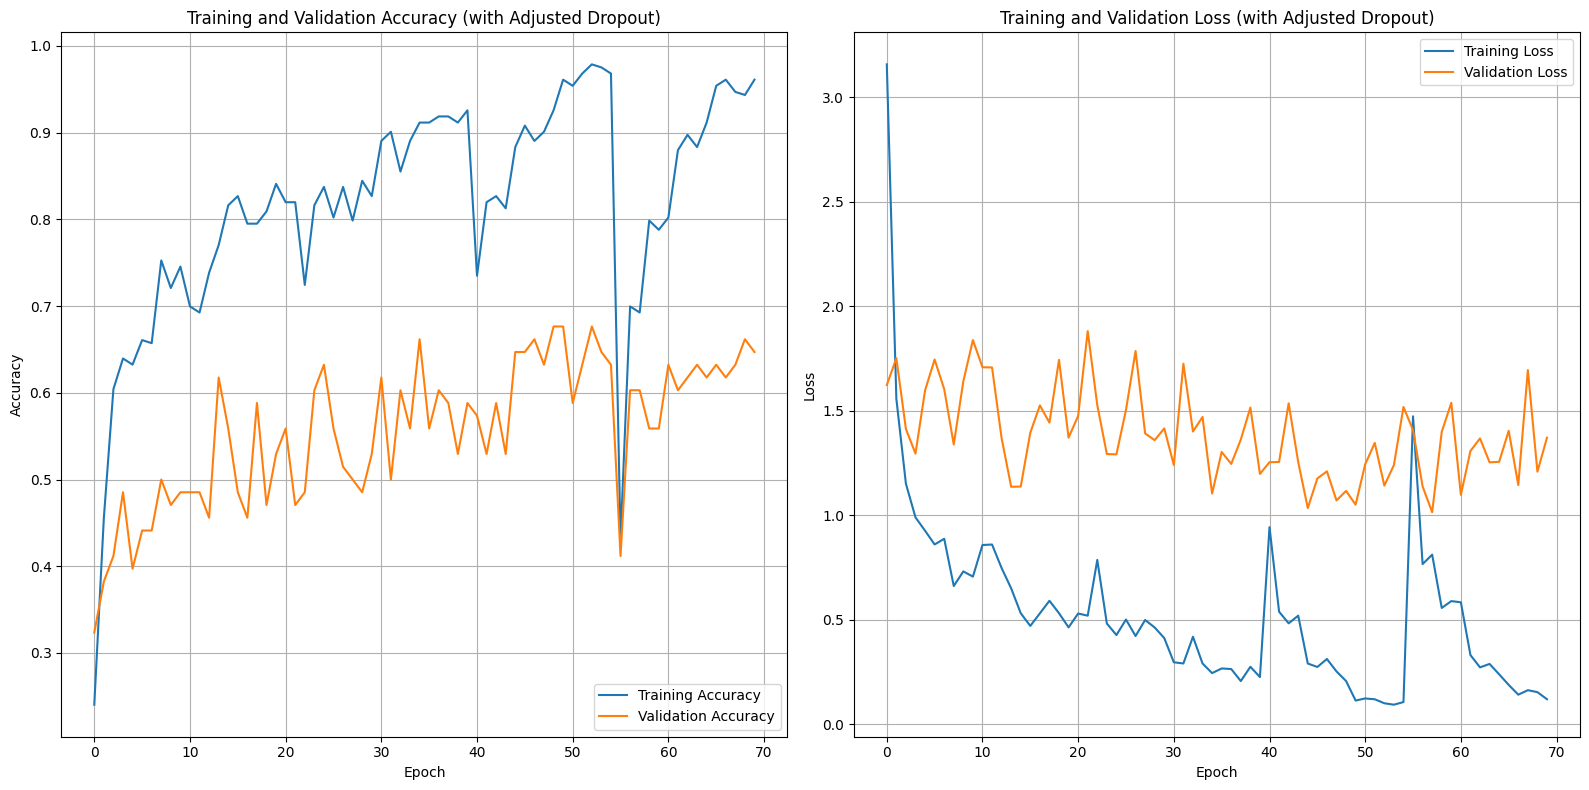

In [16]:
# Combine histories for plotting, including new dropout training phase
# Include all previous training phases as well
acc_all = training_tl.history['accuracy'] + training_fine_tune.history['accuracy'] + training_lrs.history['accuracy'] + training_dropout_adjusted.history['accuracy']
val_acc_all = training_tl.history['val_accuracy'] + training_fine_tune.history['val_accuracy'] + training_lrs.history['val_accuracy'] + training_dropout_adjusted.history['val_accuracy']

loss_all = training_tl.history['loss'] + training_fine_tune.history['loss'] + training_lrs.history['loss'] + training_dropout_adjusted.history['loss']
val_loss_all = training_tl.history['val_loss'] + training_fine_tune.history['val_loss'] + training_lrs.history['val_loss'] + training_dropout_adjusted.history['val_loss']

epochs_range_all = range(len(acc_all))

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range_all, acc_all, label='Training Accuracy')
plt.plot(epochs_range_all, val_acc_all, label='Validation Accuracy')
plt.title('Training and Validation Accuracy (with Adjusted Dropout)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range_all, loss_all, label='Training Loss')
plt.plot(epochs_range_all, val_loss_all, label='Validation Loss')
plt.title('Training and Validation Loss (with Adjusted Dropout)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

### Improving Model Stability with Batch Normalization

Since adjusting dropout rate did not yield a major improvement, **Batch Normalization** layers will be incorporated to help standardize inputs to layers, which may accelerate training, reduce need for aggressive initialization, provide a slight regularization effect, and then lead to better generalization.

In [17]:
from tensorflow.keras.layers import BatchNormalization

# Unfreeze the conv_base again
conv_base.trainable = True

# Create new model with Batch Normalization layers
model_with_bn = tf.keras.Sequential([
    conv_base,
    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(), # Add Batch Normalization layer
    Dropout(0.3),         # Keep the adjusted dropout rate
    Dense(6, activation='softmax') # Output layer for 6 classes
])

model_with_bn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,140,038 (80.64 MB)

 Trainable params: 13,504,262 (51.51 MB)

 Non-trainable params: 7,635,776 (29.13 MB)

Recompile and train model with the added Batch Normalization layer, continuing with the ReduceLROnPlateau callback.

In [18]:
# Recompile model with learning rate scheduler
model_with_bn.compile(
    optimizer=Adam(learning_rate=1e-4), # Start with 1e-4
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Define ReduceLROnPlateau callback
reduce_lr_bn = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# Train for a few more epochs with Batch Normalization and Learning Rate Scheduling
EPOCAS_BN = 15
print('Starting training with Batch Normalization and Learning Rate Scheduling...')
training_bn = model_with_bn.fit(
    datagen_train,
    epochs=EPOCAS_BN,
    steps_per_epoch=len(datagen_train),
    validation_data=datagen_validation,
    callbacks=[reduce_lr_bn] # Add the learning rate callback
)

Starting training with Batch Normalization and Learning Rate Scheduling...
Epoch 1/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 444ms/step - accuracy: 0.7102 - loss: 0.9204 - val_accuracy: 0.5588 - val_loss: 1.1654 - learning_rate: 1.0000e-04
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 315ms/step - accuracy: 0.8163 - loss: 0.5891 - val_accuracy: 0.5735 - val_loss: 1.2084 - learning_rate: 1.0000e-04
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 273ms/step - accuracy: 0.7951 - loss: 0.6421 - val_accuracy: 0.4706 - val_loss: 1.4641 - learning_rate: 1.0000e-04
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.7736 - loss: 0.7053
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 306ms/step - accuracy: 0.8021 - loss: 0.5753 - val_accuracy: 0.5294 - val_loss: 1.4438 - learning_rate: 1.0000e-04
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 378ms/step - accuracy: 0.8834 - loss: 0.3636 - val_accuracy: 0.6471 - val_loss: 1.3235 - learning_rate: 5.0

Plot training and validation curves again, including Batch Normalization results.

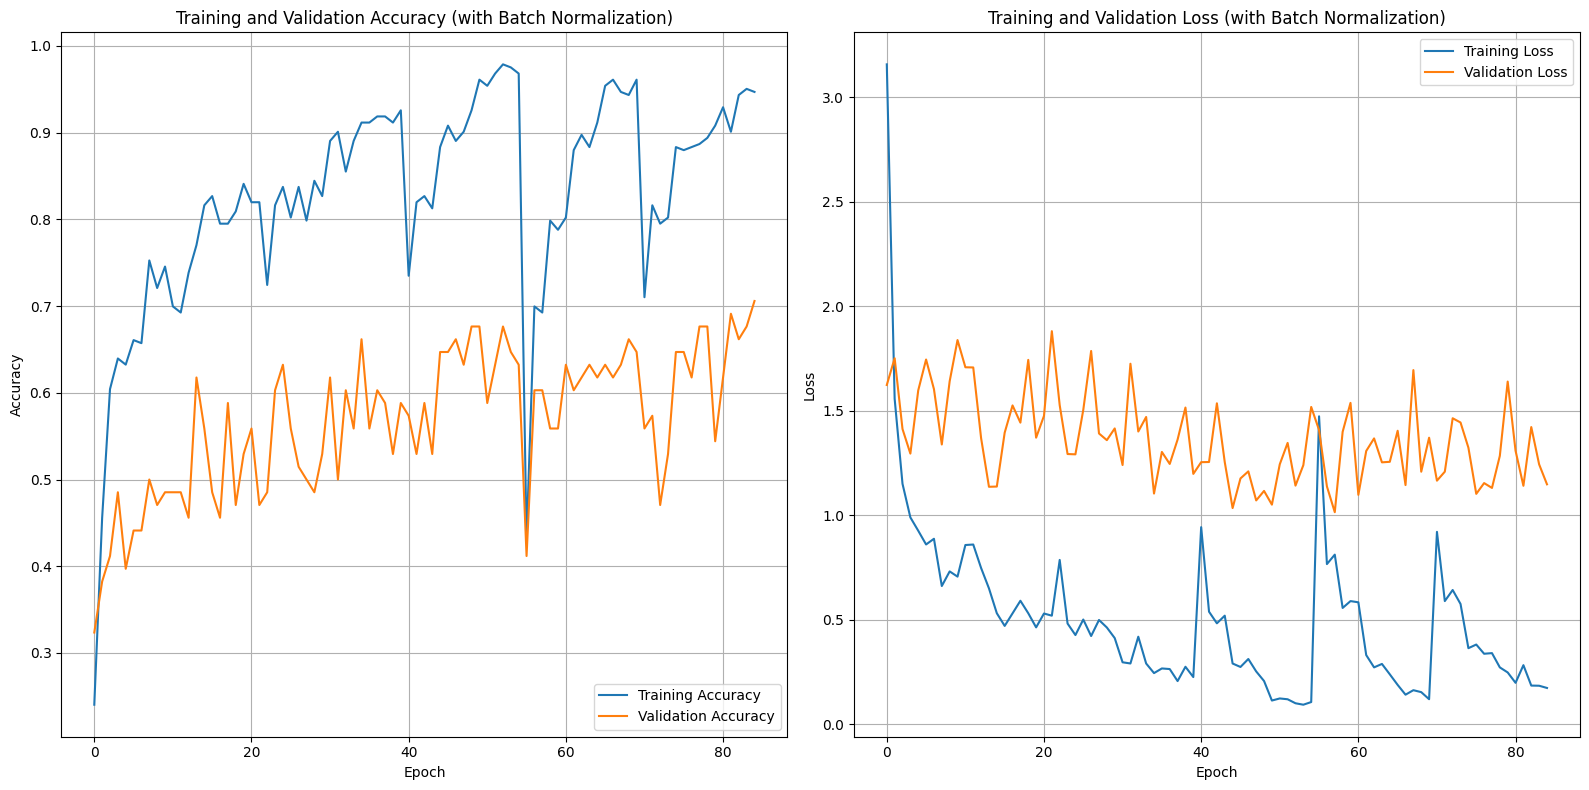

In [19]:
# Combine histories for plotting, including Batch Normalization training phase
# Include all previous training phases as well
acc_all_bn = training_tl.history['accuracy'] + training_fine_tune.history['accuracy'] + training_lrs.history['accuracy'] + training_dropout_adjusted.history['accuracy'] + training_bn.history['accuracy']
val_acc_all_bn = training_tl.history['val_accuracy'] + training_fine_tune.history['val_accuracy'] + training_lrs.history['val_accuracy'] + training_dropout_adjusted.history['val_accuracy'] + training_bn.history['val_accuracy']

loss_all_bn = training_tl.history['loss'] + training_fine_tune.history['loss'] + training_lrs.history['loss'] + training_dropout_adjusted.history['loss'] + training_bn.history['loss']
val_loss_all_bn = training_tl.history['val_loss'] + training_fine_tune.history['val_loss'] + training_lrs.history['val_loss'] + training_dropout_adjusted.history['val_loss'] + training_bn.history['val_loss']

epochs_range_all_bn = range(len(acc_all_bn))

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range_all_bn, acc_all_bn, label='Training Accuracy')
plt.plot(epochs_range_all_bn, val_acc_all_bn, label='Validation Accuracy')
plt.title('Training and Validation Accuracy (with Batch Normalization)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range_all_bn, loss_all_bn, label='Training Loss')
plt.plot(epochs_range_all_bn, val_loss_all_bn, label='Validation Loss')
plt.title('Training and Validation Loss (with Batch Normalization)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

### Modifying the Classification Head: Reducing Complexity

Since both adjusted dropout and Batch Normalization did not significantly reduce the generalization gap, the classification head will be modified by reducing its complexity. A simpler head may help prevent the model from memorizing the training data, leading to better performance on unseen data. The number of units in the Dense layer is deceased from 256 to 128.

In [20]:
#from tensorflow.keras.layers import BatchNormalization, Dropout, Dense, Flatten

# Unfreeze conv_base again
conv_base.trainable = True

# Create new model with modified (simpler) classification head
model_modified_head = tf.keras.Sequential([
    conv_base,
    Flatten(),
    Dense(128, activation='relu'), # Reduced from 256 to 128 units
    BatchNormalization(),
    Dropout(0.3),                 # Keep the adjusted dropout rate
    Dense(6, activation='softmax') # Output layer for 6 classes
])

model_modified_head.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,927,366 (68.39 MB)

 Trainable params: 10,291,846 (39.26 MB)

 Non-trainable params: 7,635,520 (29.13 MB)

Recompile and train model with simplified classification head.

In [21]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Recompile model
model_modified_head.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Define ReduceLROnPlateau callback
reduce_lr_modified = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

#Train for a few more epochs
EPOCAS_MODIFIED_HEAD = 15
print('Starting training with Modified Classification Head (Dense 128) and Learning Rate Scheduling...')
training_modified_head = model_modified_head.fit(
    datagen_train,
    epochs=EPOCAS_MODIFIED_HEAD,
    steps_per_epoch=len(datagen_train),
    validation_data=datagen_validation,
    callbacks=[reduce_lr_modified]
)

Starting training with Modified Classification Head (Dense 128) and Learning Rate Scheduling...
Epoch 1/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 476ms/step - accuracy: 0.6466 - loss: 1.0620 - val_accuracy: 0.6029 - val_loss: 1.1736 - learning_rate: 1.0000e-04
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 317ms/step - accuracy: 0.8410 - loss: 0.4844 - val_accuracy: 0.5735 - val_loss: 1.0855 - learning_rate: 1.0000e-04
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 292ms/step - accuracy: 0.8339 - loss: 0.4403 - val_accuracy: 0.6324 - val_loss: 1.1227 - learning_rate: 1.0000e-04
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 297ms/step - accuracy: 0.8410 - loss: 0.4134 - val_accuracy: 0.5882 - val_loss: 1.3348 - learning_rate: 1.0000e-04
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.8328 - loss: 0.5218
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 328ms/step - accuracy: 0.8410 - loss: 0.4473 - val_accuracy: 0.6618 - val_loss: 1.4675

Plot training and validation curves again to evaluate the impact of simplifying the classification head.

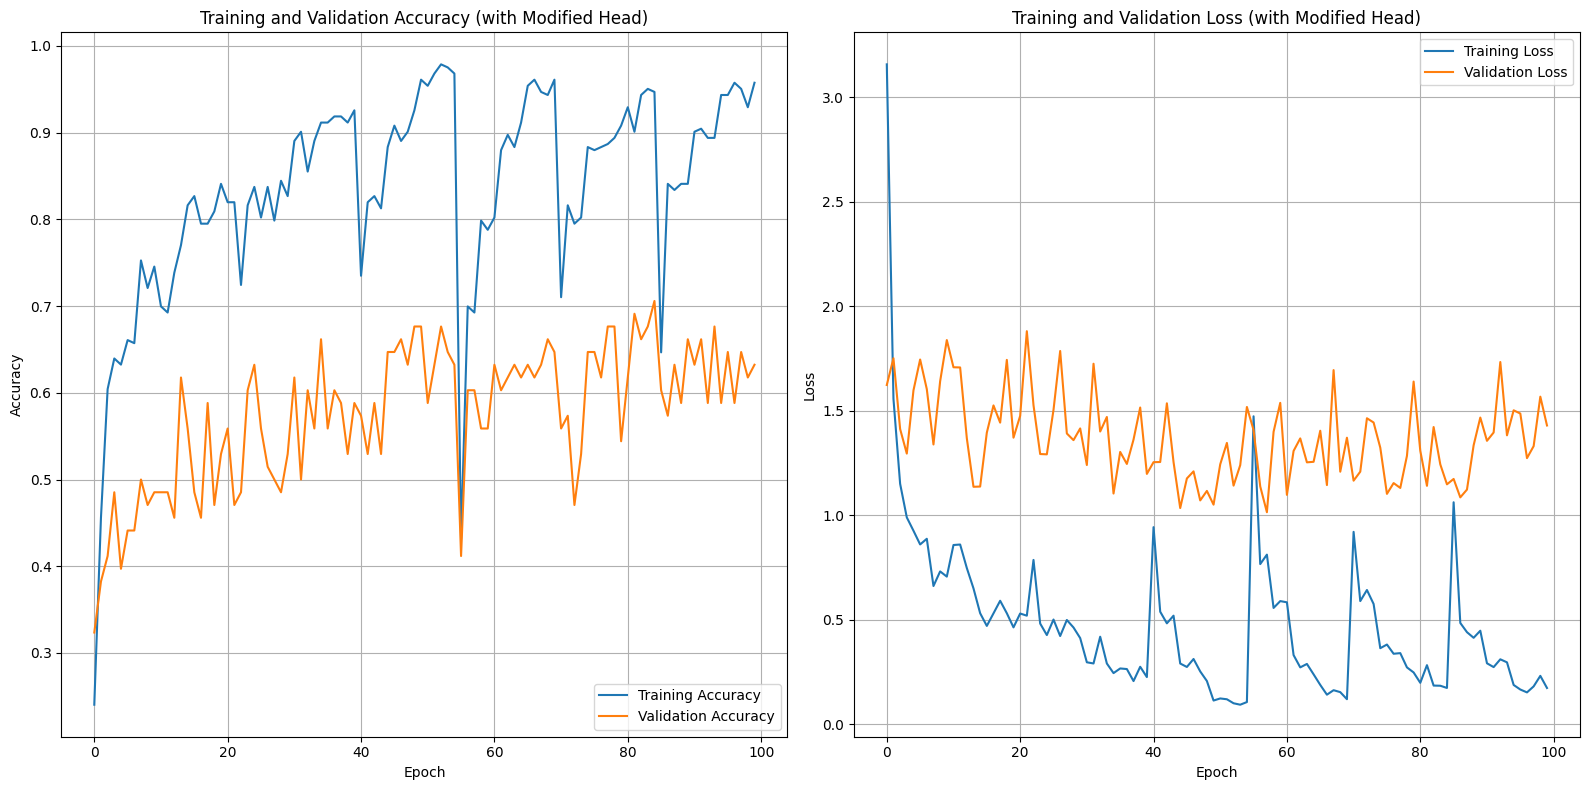

In [22]:
# Combine histories for plotting
#include the new phase with simplified head
# Include all previous training phases
acc_final = training_tl.history['accuracy'] + \
            training_fine_tune.history['accuracy'] + \
            training_lrs.history['accuracy'] + \
            training_dropout_adjusted.history['accuracy'] + \
            training_bn.history['accuracy'] + \
            training_modified_head.history['accuracy']

val_acc_final = training_tl.history['val_accuracy'] + \
                training_fine_tune.history['val_accuracy'] + \
                training_lrs.history['val_accuracy'] + \
                training_dropout_adjusted.history['val_accuracy'] + \
                training_bn.history['val_accuracy'] + \
                training_modified_head.history['val_accuracy']

loss_final = training_tl.history['loss'] + \
             training_fine_tune.history['loss'] + \
             training_lrs.history['loss'] + \
             training_dropout_adjusted.history['loss'] + \
             training_bn.history['loss'] + \
             training_modified_head.history['loss']

val_loss_final = training_tl.history['val_loss'] + \
                 training_fine_tune.history['val_loss'] + \
                 training_lrs.history['val_loss'] + \
                 training_dropout_adjusted.history['val_loss'] + \
                 training_bn.history['val_loss'] + \
                 training_modified_head.history['val_loss']

epochs_range_final = range(len(acc_final))

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range_final, acc_final, label='Training Accuracy')
plt.plot(epochs_range_final, val_acc_final, label='Validation Accuracy')
plt.title('Training and Validation Accuracy (with Modified Head)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range_final, loss_final, label='Training Loss')
plt.plot(epochs_range_final, val_loss_final, label='Validation Loss')
plt.title('Training and Validation Loss (with Modified Head)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

### Saving and Loading Model

Save model_modified_head in the TensorFlow SavedModel format (recommended approach for Keras models). This format preserves the model's architecture, weights, and optimizer state, allowing easy reloading.


In [23]:
import os

# Define path to save model, adding the .keras extension
model_save_path = 'model_modified_head.keras'

# Save entire model in the TensorFlow SavedModel format
# (Keras automatically handles the format based on the extension)
model_modified_head.save(model_save_path)
print(f"Model saved to: {model_save_path}")

# To confirm the model is saved, list the contents of the directory
# This should show the single .keras file
print("Contents of saved model directory (if applicable for .keras format):")
if os.path.exists(model_save_path):
    print(f"  {model_save_path} (file)")
else:
    # If saved as a directory (e.g., SavedModel format if no extension provided, which is now an error)
    # If the file is within a directory for .keras, check the folder if it is a directory.
    # In Keras 3 with .keras, it is typically a single file.
    print(f"  Could not find file: {model_save_path}")
    print("  Please check the directory where it was intended to be saved.")

Model saved to: model_modified_head.keras
Contents of saved model directory (if applicable for .keras format):
  model_modified_head.keras (file)


In [24]:
from tensorflow.keras.models import load_model
import joblib

# 1. Load your trained model in Colab
model = load_model('model_modified_head.keras')

# 2. Extract just the raw mathematical numbers array matrix
raw_weights = model.get_weights()

# 3. Export them as a lightweight, platform-independent file
joblib.dump(raw_weights, 'brain_coral_weights.pkl')
print("🎉 Success! Raw weights exported safely to brain_coral_weights.pkl")

🎉 Success! Raw weights exported safely to brain_coral_weights.pkl
